# Exemplos do Dataset HFUS — BW e Doppler, Benigno e Maligno

Gera uma figura 2x2 com exemplos representativos do dataset (`data/images-alfageme`).
Cada linha corresponde a uma modalidade (BW e Doppler) e cada coluna a uma classe
(benigno e maligno). Por padrao, a mesma lesao benigna e a mesma lesao maligna sao
exibidas nas duas modalidades, permitindo a comparacao direta entre BW e Doppler
para a secao de discussao do paper.

- **Labels:** definidos pelas pastas `CLASSES/classe_m` (maligno) e `CLASSES/classe_b` (benigno)
- **Pixels:** lidos de `data/images-alfageme/images/bw/<id>_bw.jpg` e `<id>_doppler.jpg`

## Env Configuration

Importacoes, caminhos do dataset, IDs das lesoes escolhidas para cada classe e diretorio de saida da figura.

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
IMAGES_DIR   = os.path.join(PROJECT_ROOT, 'data', 'images-alfageme', 'images', 'bw')
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, 'data', 'images')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# IDs das lesoes exibidas. A mesma lesao e mostrada em BW e Doppler.
# Trocar por outros IDs (ver CLASSES/classe_b e CLASSES/classe_m) se desejar.
BENIGN_ID    = '02'   # classe_b (benigno)
MALIGNANT_ID = '11'   # classe_m (maligno)

# Estrutura do grid: linhas = modalidade, colunas = classe.
# Cada celula: (sufixo do arquivo, id, titulo da coluna).
PANELS = [
    [('bw',      BENIGN_ID,    'Benigno'), ('bw',      MALIGNANT_ID, 'Maligno')],
    [('doppler', BENIGN_ID,    'Benigno'), ('doppler', MALIGNANT_ID, 'Maligno')],
]
ROW_LABELS = ['BW', 'Doppler']

print('IMAGES_DIR:', IMAGES_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)
print(f'Benigno: id {BENIGN_ID} | Maligno: id {MALIGNANT_ID}')

IMAGES_DIR: /Users/lucasgambim/Documents/TCC-PROJECT/data/images-alfageme/images/bw
OUTPUT_DIR: /Users/lucasgambim/Documents/TCC-PROJECT/data/images
Benigno: id 02 | Maligno: id 11


## Process

1. Monta o caminho de cada imagem a partir do id e do sufixo de modalidade
2. Le os 4 arquivos e os organiza em um grid 2x2
3. Anota as colunas (Benigno / Maligno) e as linhas (BW / Doppler)
4. Salva a figura em `experiments/dataset_examples/`

Figura salva em: /Users/lucasgambim/Documents/TCC-PROJECT/data/images/dataset_examples.png


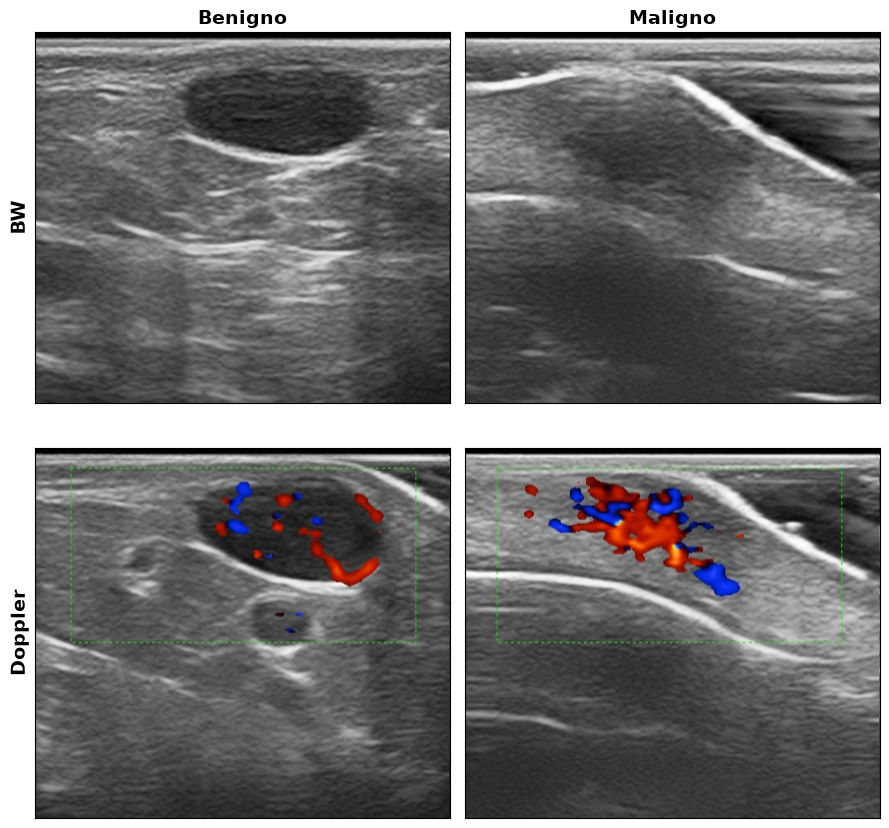

In [7]:
def image_path(suffix, image_id):
    """Caminho do arquivo .jpg para um id e uma modalidade ('bw' ou 'doppler')."""
    return os.path.join(IMAGES_DIR, f'{image_id}_{suffix}.jpg')


fig, axes = plt.subplots(2, 2, figsize=(9, 9))

for r, row in enumerate(PANELS):
    for c, (suffix, image_id, col_title) in enumerate(row):
        ax   = axes[r, c]
        path = image_path(suffix, image_id)
        ax.imshow(mpimg.imread(path), cmap='gray' if suffix == 'bw' else None)
        ax.set_xticks([])
        ax.set_yticks([])
        # Titulo da classe apenas na primeira linha
        if r == 0:
            ax.set_title(col_title, fontsize=14, fontweight='bold')
        # Rotulo da modalidade apenas na primeira coluna
        if c == 0:
            ax.set_ylabel(ROW_LABELS[r], fontsize=14, fontweight='bold')
        ax.text(0.02, 0.98, f'', transform=ax.transAxes,
                fontsize=9, color='white', va='top', ha='left',
                bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

fig.suptitle('', fontsize=16, fontweight='bold')
fig.tight_layout()

out_path = os.path.join(OUTPUT_DIR, 'dataset_examples.png')
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print('Figura salva em:', out_path)
plt.show()